# **Section 9: XGBoost Classification**

In this notebook, I will train and evaluate XGBoost (Gradient Boosting) models. XGBoost is particularly well-suited for high-dimensional genomic data with limited samples. I will start with a baseline model and then tune hyperparameters using cross-validated grid search.


## **1. Importing the Data**

Let's import the data and split it into training, validation and test sets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
sns.set_palette("pastel")

### **1.1 Load Features**

In [2]:
# Load features and labels
cnv_train = pd.read_csv("Data/cnv_train.csv", index_col=0)
cnv_test = pd.read_csv("Data/cnv_test.csv", index_col=0)
profiles_train = pd.read_csv("Data/SXT_train.csv", index_col=0)
profiles_test = pd.read_csv("Data/SXT_test.csv", index_col=0)

X_train = cnv_train.values
y_train = profiles_train.values

X_test = cnv_test.values
y_test = profiles_test.values

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Categories: {np.unique(y_train)}")

Training set shape: (173, 7197)
Test set shape: (48, 7197)
Categories: [0 1]


## **2. XGBoost with Default Hyperparameters**

Let's start with a baseline XGBoost model using default parameters.

In [3]:
# Create XGBoost model (no scaling needed for tree-based models)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### **2.1 Evaluate Baseline Model**

In [4]:
# Evaluate on training, validation, and test sets
accuracy_train = xgb_model.score(X_train, y_train)
accuracy_test = xgb_model.score(X_test, y_test)

print(f"Accuracy training set: {accuracy_train:.4f}")
print(f"Accuracy test set: {accuracy_test:.4f}")

Accuracy training set: 1.0000
Accuracy test set: 0.9792


### **2.2 Feature Importance (Baseline)**

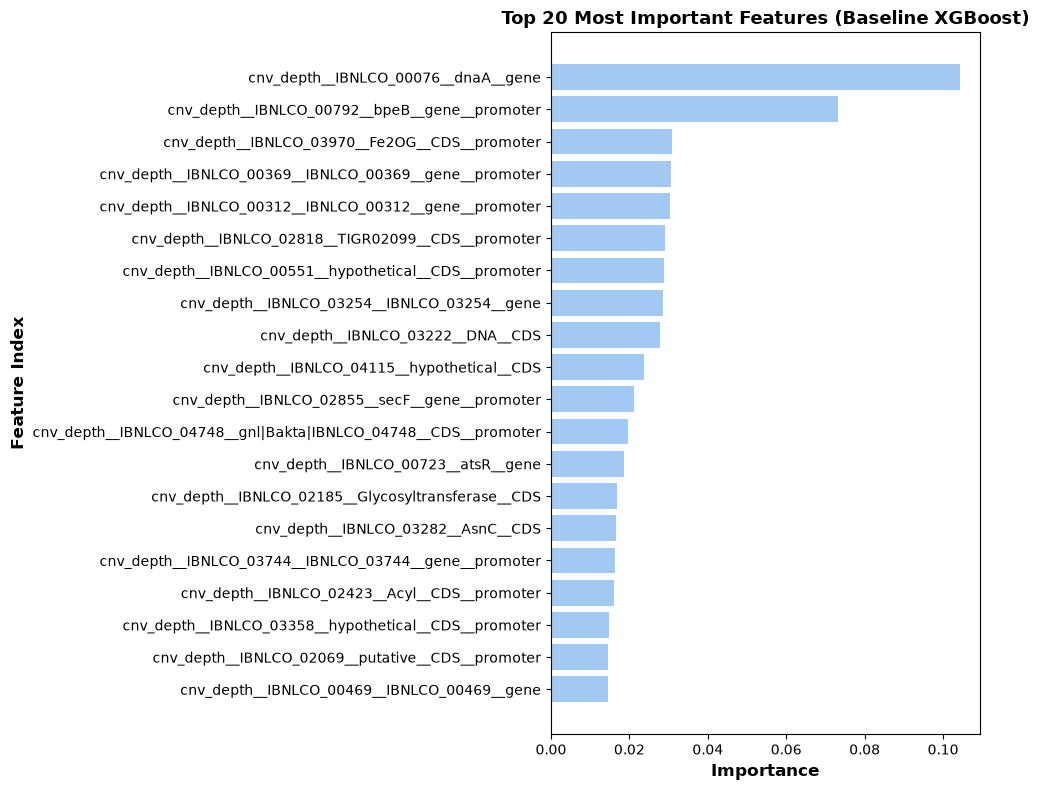


Top 10 most important features:
                                           feature_name  importance
138                 cnv_depth__IBNLCO_00076__dnaA__gene    0.104206
1048      cnv_depth__IBNLCO_00792__bpeB__gene__promoter    0.073143
4967      cnv_depth__IBNLCO_03970__Fe2OG__CDS__promoter    0.030861
539   cnv_depth__IBNLCO_00369__IBNLCO_00369__gene__p...    0.030683
458   cnv_depth__IBNLCO_00312__IBNLCO_00312__gene__p...    0.030334
3349  cnv_depth__IBNLCO_02818__TIGR02099__CDS__promoter    0.029045
779   cnv_depth__IBNLCO_00551__hypothetical__CDS__pr...    0.028859
4015        cnv_depth__IBNLCO_03254__IBNLCO_03254__gene    0.028521
3964                  cnv_depth__IBNLCO_03222__DNA__CDS    0.027805
5107         cnv_depth__IBNLCO_04115__hypothetical__CDS    0.023674


In [5]:
# Get feature importances
feature_importance_df = pd.DataFrame({
    "feature_name": cnv_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance_df['importance'].head(20))
plt.yticks(range(20), feature_importance_df['feature_name'].head(20))
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature Index', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features (Baseline XGBoost)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feature_importance_df.head(10))

### **2.3 Classification Report and Confusion Matrix**

In [6]:
# Get predictions
y_test_pred = xgb_model.predict(X_test)

# Classification report
print("Classification Report (Baseline XGBoost):")
print(classification_report(y_test, y_test_pred))

Classification Report (Baseline XGBoost):
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.95      1.00      0.97        19

    accuracy                           0.98        48
   macro avg       0.97      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48



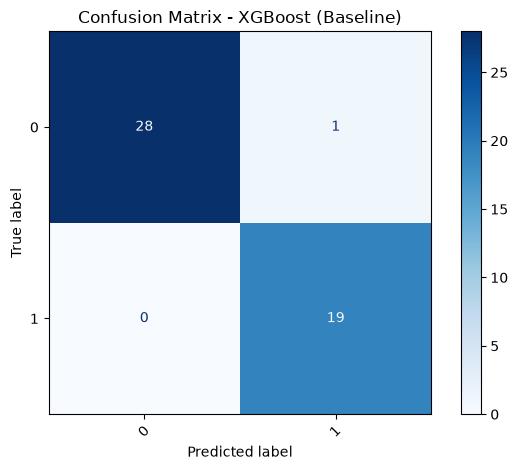

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=xgb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - XGBoost (Baseline)")
plt.tight_layout()
plt.show()

## **3. Hyperparameter Tuning: Optimizing Regularization and Tree Parameters**

Now let's use cross-validated grid search to find optimal hyperparameters.

### **3.1 Grid Search for Optimal Hyperparameters**

In [8]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'reg_alpha': [0.0, 0.1],  # L1 regularization
    'reg_lambda': [0.1, 1.0]  # L2 regularization
}

# Create grid search
grid_search = GridSearchCV(
    xgb.XGBClassifier(
        n_estimators=100,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    param_grid,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Perform grid search
print("Performing grid search")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Performing grid search

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
Best cross-validation score: 0.8728


### **3.3 Analyze Grid Search Results**

In [13]:
# Extract results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display top results
results_display = cv_results[[
    'mean_test_score', 'std_test_score', 
    'mean_train_score', 'std_train_score',
    'param_max_depth', 'param_learning_rate', 'param_reg_alpha', 'param_reg_lambda'
]].sort_values('mean_test_score', ascending=False).head(10)

print("\nTop 10 Grid Search Results:")
print(results_display)


Top 10 Grid Search Results:
    mean_test_score  std_test_score  mean_train_score  std_train_score  \
2          0.872773        0.086229               1.0              0.0   
10         0.872773        0.086229               1.0              0.0   
6          0.872773        0.086229               1.0              0.0   
4          0.872773        0.096926               1.0              0.0   
8          0.872773        0.096926               1.0              0.0   
11         0.867059        0.095136               1.0              0.0   
0          0.867059        0.095136               1.0              0.0   
3          0.867059        0.095136               1.0              0.0   
7          0.867059        0.095136               1.0              0.0   
1          0.866891        0.100561               1.0              0.0   

    param_max_depth  param_learning_rate  param_reg_alpha  param_reg_lambda  
2                 3                 0.05              0.1               0.1  


### **3.4 Visualize Learning Rate Effect**

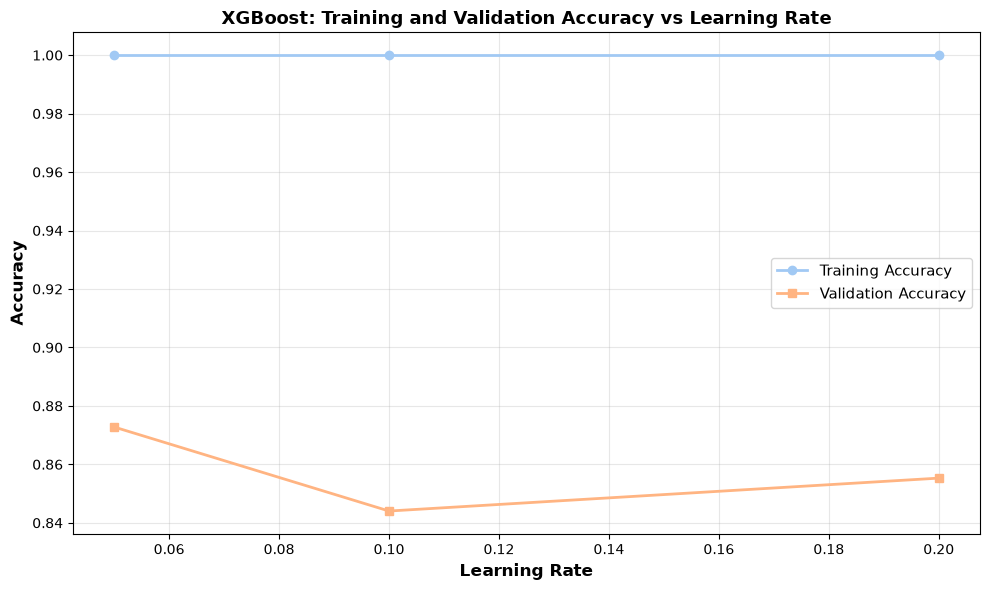

In [14]:
# Filter results for best max_depth
best_max_depth = grid_search.best_params_['max_depth']
best_reg_alpha = grid_search.best_params_['reg_alpha']
best_reg_lambda = grid_search.best_params_['reg_lambda']

filtered_results = cv_results[
    (cv_results['param_max_depth'] == best_max_depth) &
    (cv_results['param_reg_alpha'] == best_reg_alpha) &
    (cv_results['param_reg_lambda'] == best_reg_lambda)
].sort_values('param_learning_rate')

if len(filtered_results) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(
        filtered_results['param_learning_rate'],
        filtered_results['mean_train_score'],
        label='Training Accuracy',
        marker='o',
        linewidth=2
    )
    plt.plot(
        filtered_results['param_learning_rate'],
        filtered_results['mean_test_score'],
        label='Validation Accuracy',
        marker='s',
        linewidth=2
    )
    
    plt.xlabel('Learning Rate', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.title('XGBoost: Training and Validation Accuracy vs Learning Rate', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## **4. Evaluate Best Model**

In [15]:
# Evaluate best model on test set
best_xgb = grid_search.best_estimator_
accuracy_test_best = best_xgb.score(X_test, y_test)

print(f"\nBest Model Test Accuracy: {accuracy_test_best:.4f}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")


Best Model Test Accuracy: 1.0000
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
Best CV score: 0.8728


### **4.1 Feature Importance of Best Model**

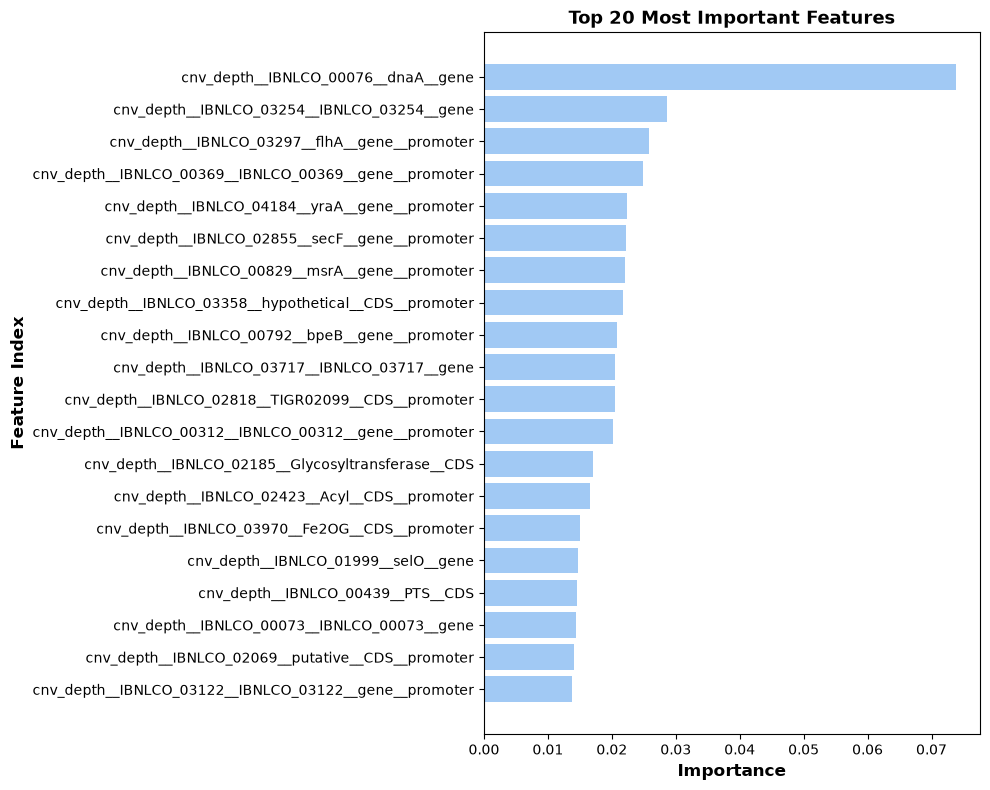


Top 10 most important features (tuned model):
                                           feature_name  importance
138                 cnv_depth__IBNLCO_00076__dnaA__gene    0.073888
4015        cnv_depth__IBNLCO_03254__IBNLCO_03254__gene    0.028651
4091      cnv_depth__IBNLCO_03297__flhA__gene__promoter    0.025872
539   cnv_depth__IBNLCO_00369__IBNLCO_00369__gene__p...    0.024942
5187      cnv_depth__IBNLCO_04184__yraA__gene__promoter    0.022316
3394      cnv_depth__IBNLCO_02855__secF__gene__promoter    0.022183
1078      cnv_depth__IBNLCO_00829__msrA__gene__promoter    0.022117
4180  cnv_depth__IBNLCO_03358__hypothetical__CDS__pr...    0.021675
1048      cnv_depth__IBNLCO_00792__bpeB__gene__promoter    0.020789
4684        cnv_depth__IBNLCO_03717__IBNLCO_03717__gene    0.020524


In [23]:
# Get feature importances
feature_importance_df = pd.DataFrame({
    "feature_name": cnv_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance_df['importance'].head(20))
plt.yticks(range(20), feature_importance_df['feature_name'].head(20))
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature Index', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features (tuned model):")
print(feature_importance_df.head(10))

feature_importance_df.to_csv("Results/biomarkers_xgboost.csv")

### **4.2 Classification Report**

In [18]:
# Get predictions
y_test_pred_best = best_xgb.predict(X_test)

# Classification report
print("\nClassification Report (Best XGBoost):")
print(classification_report(y_test, y_test_pred_best))


Classification Report (Best XGBoost):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        19

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



### **4.3 Confusion Matrix**

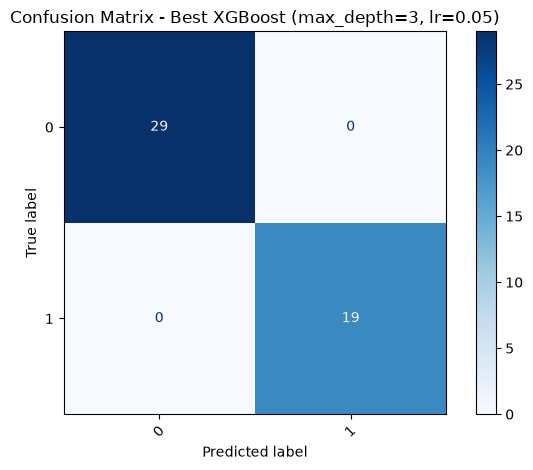

In [19]:
# Confusion matrix
cm_best = confusion_matrix(y_test, y_test_pred_best, labels=best_xgb.classes_)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=best_xgb.classes_)
disp_best.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best XGBoost (max_depth={grid_search.best_params_['max_depth']}, lr={grid_search.best_params_['learning_rate']})")
plt.tight_layout()
plt.show()

### **4.4 ROC Curve and AUC Score**

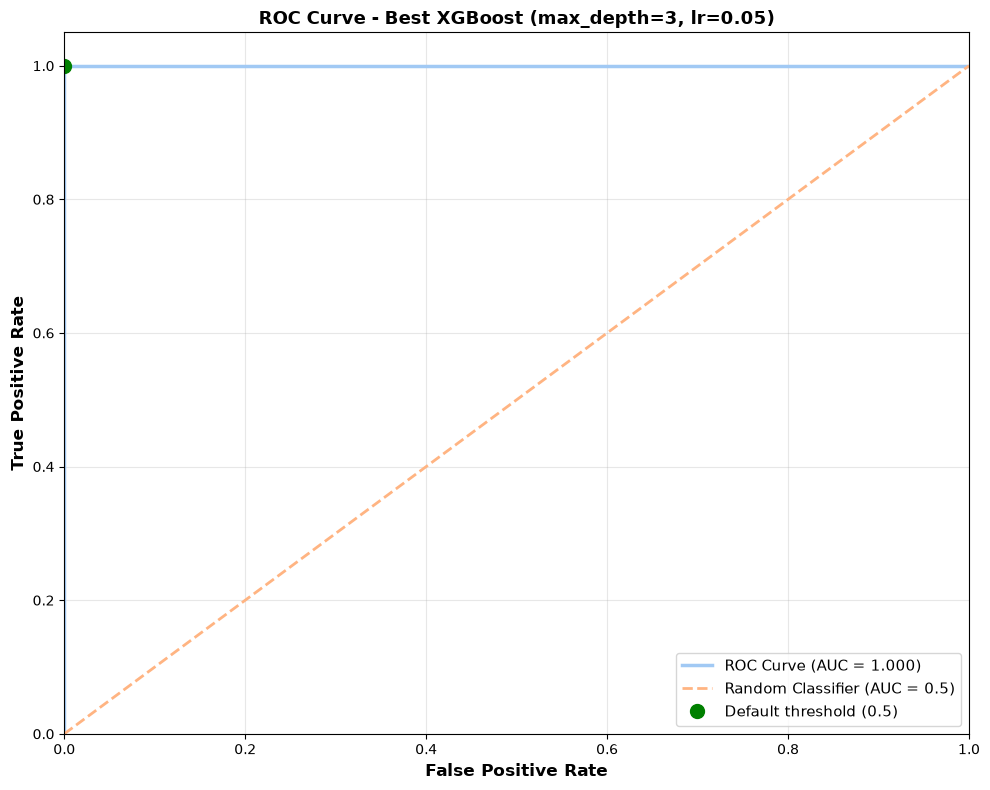


AUC Score: 1.0000
At default threshold (0.5):
  True Positive Rate (TPR): 1.000 (catch 100.0% of resistant)
  False Positive Rate (FPR): 0.000 (0.0% of susceptible misclassified)


In [20]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for the positive class
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark the default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(fpr[default_idx], tpr[default_idx], 'go', markersize=10, label='Default threshold (0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC Curve - Best XGBoost (max_depth={grid_search.best_params_["max_depth"]}, lr={grid_search.best_params_["learning_rate"]})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")
print(f"At default threshold (0.5):")
print(f"  True Positive Rate (TPR): {tpr[default_idx]:.3f} (catch {tpr[default_idx]*100:.1f}% of resistant)")
print(f"  False Positive Rate (FPR): {fpr[default_idx]:.3f} ({fpr[default_idx]*100:.1f}% of susceptible misclassified)")

## **5. Save Results**

In [22]:
import csv
import os

# Store results
results = {
    'model': 'XGBoost',
    'hyperparameters': f"max_depth={grid_search.best_params_['max_depth']}, learning_rate={grid_search.best_params_['learning_rate']}, reg_alpha={grid_search.best_params_['reg_alpha']}, reg_lambda={grid_search.best_params_['reg_lambda']}",
    'test_accuracy': float(accuracy_test_best),
    'cv_score': float(grid_search.best_score_)
}

csv_file = 'Results/model_results.csv'

# Append results to the csv file
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writeheader()
        writer.writerow(results)
else:
    with open(csv_file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writerow(results)

print(f"\nResults saved:")
print(f"  Model: {results['model']}")
print(f"  Hyperparameters: {results['hyperparameters']}")
print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
print(f"  CV Score: {results['cv_score']:.4f}")


Results saved:
  Model: XGBoost
  Hyperparameters: max_depth=3, learning_rate=0.05, reg_alpha=0.1, reg_lambda=0.1
  Test Accuracy: 1.0000
  CV Score: 0.8728


In [ ]:
!